# Projet de Machine Learning (Python)

## Création des échantillons train et test

**Divisez le jeu de données en un échantillon d’apprentissage et un échantillon test. Vous prendrez un pourcentage de 20% pour l’échantillon test. Pourquoi cette étape est-elle nécessaire lorsque nous nous concentrons sur les performances des algorithmes ?**

Le fait d'entraîner et de tester le modèle sur deux échantillons distincts permet de tester ses véritables performances face à des données nouvelles. Si l'on testait sur l'échantillon d'apprentissage, les performances seraient artificiellement meilleures et nous ne pourrions pas détecter un surapprentissage éventuel.

In [8]:
import pandas as pd
import numpy as np

seed = 42  #seed pour la reproductibilité

In [9]:
df = pd.read_csv('healthcare_synthetic_data.csv')  # Création du dataframe
print(f"Dimensions : {df.shape}") # Affichage de ses dimensions
df.head() # Affichage des 5 premières lignes du df

Dimensions : (15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [10]:
# Nous remarquons que les variables qualitatives sont deja encodées numériquement (en états 0,1,2), nous n'avons donc rien à changer ici.

# Suppression de Patient_ID car inutile dans notre tâche de classification
df = df.drop(columns=['Patient_ID'])

# Création de listes par type de variable
quant_vars = ['Age','Height_cm','Weight_kg','BMI','Systolic_BP','Diastolic_BP',
              'Cholesterol_Total','Cholesterol_LDL','Cholesterol_HDL',
              'Fasting_Blood_Sugar','Stress_Level','Sleep_Hours']

qual_vars  = ['Gender','Smoking_Status','Alcohol_Consumption',
              'Physical_Activity_Level','Family_History']

var_cls = 'Heart_Disease_Risk'  #Variable à classifier
var_reg = 'Cholesterol_LDL'  #Variable pour la régression

# Affichage des différentes variables
print("Variables quantitatives :", quant_vars)
print("\n")
print("Variables qualitatives (encodées) :", qual_vars)
print("\n")
print("Cibles :", var_cls, '|', var_reg)

Variables quantitatives : ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours']


Variables qualitatives (encodées) : ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History']


Cibles : Heart_Disease_Risk | Cholesterol_LDL


In [11]:
# Division des données en train (80%) et test (20%) pour la CLASSIFICATION

from sklearn.model_selection import train_test_split
df_cls = df.copy()  # Création d'un dataframe spécifique à la classification (protection sur df)

# Création d'une liste des variables pour la classification (toutes les variables sauf 'Heart_Disease_Risk')
variables_cls = [c for c in df_cls.columns if c != var_cls]

X_cls = df_cls[variables_cls] # Création d'un dataframe qui ne contient que les variables utiles à la tâche de classification
y_cls = df_cls[var_cls] # Création d'un dataframe d'une colonne qui contient la variable à classifier ('Heart_Disease_Risk')

# Division 80/20
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.20, random_state=seed, stratify=y_cls)
                                #stratify=y_cls permet de garantir que chaque classe est bien représentée dans le train et test

In [12]:
#Division des données en train (80%) et test (20%) pour la RÉGRESSION

from sklearn.model_selection import train_test_split
df_reg = df.copy() # Création d'un dataframe spécifique à la régression (protection sur df)

# Création d'une liste des variables pour la régression (toutes les variables sauf 'Heart_Disease_Risk' et 'Cholesterol_LDL')
variables_reg = [c for c in df_cls.columns if c != var_cls and c!=var_reg]


X_reg = df_reg[variables_reg] # Création d'un dataframe qui ne contient que les variables utiles à la tâche de régression
y_reg = df_reg[var_reg] # Création d'un dataframe d'une colonne qui contient la variable à prédire par régression ('Cholesterol_LDL')

# Division 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.20, random_state=seed)
                                                        # On ne peut pas utiliser stratify ici car var_reg est continue (régression)


Avant de commencer les tâches de classification et de régression, nous devons **standardiser** nos variables explicatives.

En effet, puisque que nos variables ont des ordres de grandeur et des unités très différents, nous devons les ramener à la même échelle. Sans cette étape de standardisation, les méthodes basées sur les distances (comme SVM) ou sur la descente de gradient (comme la Régression Logistique ou Ridge) accorderaient artificiellement plus de poids aux variables ayant les plus grandes valeurs.

In [13]:
from sklearn.preprocessing import StandardScaler 

#Classification
scaler = StandardScaler()  
scaler.fit(X_train_c) # Calcul de la moyenne et de l'écart-type de chaque variables du train (évite la fuite de données)
Xr_train_c = scaler.transform(X_train_c) # On applique la transformation (. - moyenne_var)/std sur le train
Xr_test_c = scaler.transform(X_test_c) # On applique la transformation (. - moyenne_var)/std sur le test



#Régression
scaler = StandardScaler()  
scaler.fit(X_train_r)  
Xr_train_r = scaler.transform(X_train_r)
Xr_test_r = scaler.transform(X_test_r)

## A. Modèles de classification pour la variable 'Heart_Disease_Risk'

### I. Modèles linéaires

#### I. a) Régression logistique (GLM)

In [14]:
#On commence par un GLM classique pour la classification : la régression logistique.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres (C = 1/λ)
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(solver="liblinear", random_state=42), param,cv=5,n_jobs=-1)  #=> en sklearn=1.8.0, le default est d'avoir une pénalité l2
                                        #Pour avoir une logit pure, il faut absolument mettre C=np.inf et donc pas de GridSearch.....
logitOpt=logit.fit(Xr_train_c, y_train_c)

logitOpt=LogisticRegression(C=np.inf, random_state=42).fit(Xr_train_c, y_train_c) # Logit pure

/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [15]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Prédictions
y_pred_logit = logitOpt.predict(Xr_test_c)

#Table de résultats
table = pd.crosstab(y_test_c, y_pred_logit,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

#print(f"Meilleur C (Logit): {logitOpt.best_params_['C']}")
#print(f"Accuracy CV (train, Logit): {logitOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Logit) : {accuracy_score(y_test_c, y_pred_logit)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_logit)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_logit)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1376,316
Risque (1),469,839


Accuracy globale (test, Logit) : 73.8333%
Rappel (Détection vrais malades) : 64.1437%
Précision (Fiabilité des alertes) : 72.6407%


La régression logistique aboutit en un classificateur qui a une **performance globale** de 73.83%. C'est un très bon score, surtout pour des données médicales (même si elles sont synthétiques) où le hasard joue souvent une grande part.
Nous remarquons cependant que le **rappel** (la détection des vrais malades) n'est que de 64.14%, ce qui est plus faible que la **précision** (la fiabilité des alertes) qui est de 72.64%. Concrètement, notre modèle génère 469 Faux Négatifs, ce qui n'est pas satisfaisant dans un contexte médical. 

Dans le secteur médical, il est préférable d'avoir un fort rappel car cela permet de détecter plus de malade, quitte à lancer des fausses alertes plus souvent. Il serait donc préférable de dégrader légèrement la précision du modèle afin d'augmenter le rappel.

#### I. b) Ridge (pénalisation sans sélection de variables)

In [16]:
#On continue sur de la pénalisation sans sélection de variables : Ridge

# Grille d'hyperparamètres (C = 1/λ)
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}
# ridge = GridSearchCV(LogisticRegression(penalty="l2", solver="liblinear"),param,cv=5,n_jobs=-1)
                                # En sklearn 1.8, penalty a été deprecated => penalty='l2'~l1_ratio=0 (default), penalty='l1'~l1_ratio=1, penalty='elasticnet'~l1_ratio=any_float
ridge = GridSearchCV(LogisticRegression(l1_ratio=0, solver="liblinear", random_state=42),param,cv=5,n_jobs=-1)
ridgeOpt = ridge.fit(Xr_train_c, y_train_c)


In [17]:
# Prédictions
y_pred_ridge = ridgeOpt.best_estimator_.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_ridge,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (Ridge): {ridgeOpt.best_params_['C']}")
print(f"Accuracy CV (train, Ridge): {ridgeOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Ridge) : {accuracy_score(y_test_c, y_pred_ridge)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_ridge)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_ridge)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1375,317
Risque (1),467,841


Meilleur C (Ridge): 0.01
Accuracy CV (train, Ridge): 73.8417%
Accuracy globale (test, Ridge) : 73.8667%
Rappel (Détection vrais malades) : 64.2966%
Précision (Fiabilité des alertes) : 72.6252%


L'ajout d'une pénalité L² (Ridge) aboutit en un classificateur qui a une **performance globale** de 73.87%, ce qui est très légèrement supérieur à la régression logistique classique.
Nous remarquons là encore que le **rappel** (la détection des vrais malades) est plus faible que la **précision** (la fiabilité des alertes): 64.30% contre 72.63%. 

Nous remarquons cependant une légère amélioration du rappel grâce au Ridge. En effet, le nombre de Faux Négatifs a été réduit à 467, contre 469 pour le modèle Logit pur. Concrètement le modèle Ridge a permis de détecter correctement 2 malades supplémentaires par rapport au modèle de régression logistique pure

Coefficients de Ridge : [ 2.31616900e-01 -3.08950223e-02 -3.66611940e-02  9.74895149e-02
  1.13224169e-01  3.11639173e-01  1.13683956e-04  8.14219025e-03
  1.59726676e-01 -3.79377015e-02  2.87969283e-01  8.60591446e-01
 -1.14898533e-02 -4.24968474e-01  4.97882752e-01  2.76442781e-01
 -8.63310673e-02]


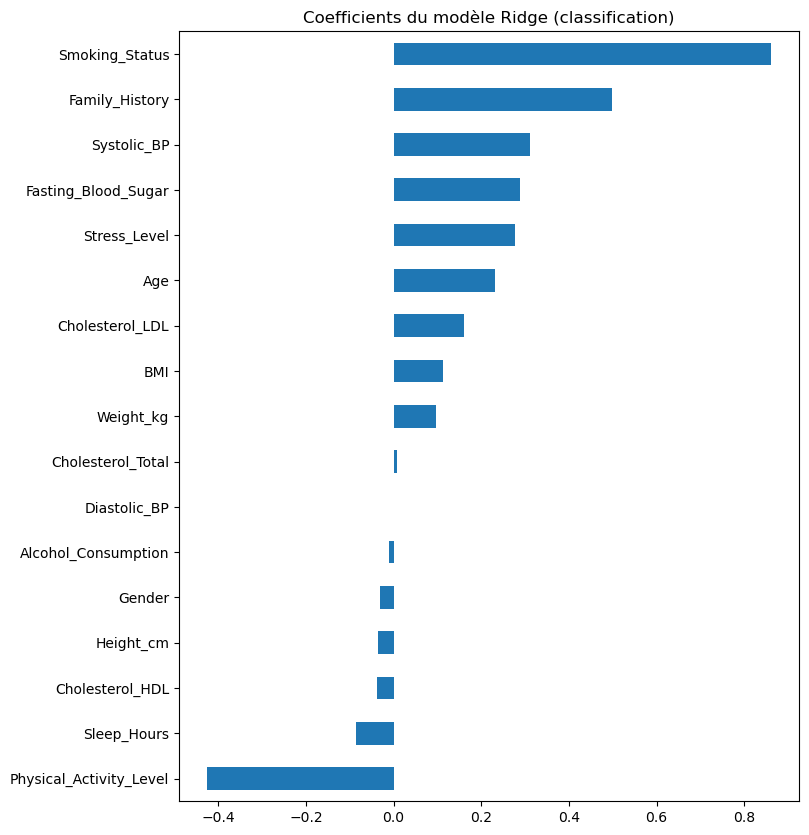

In [18]:
import matplotlib.pyplot as plt

# Coefficients du meilleur modèle
ridgeCoef = ridgeOpt.best_estimator_.coef_[0]
print(f"Coefficients de Ridge : {ridgeCoef}")

coef = pd.Series(ridgeCoef, index=X_train_c.columns)


# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle Ridge (classification)")
plt.show()

L'affichage des coefficients du modèle Ridge illustre parfaitement le fonctionnement mathématique de la pénalisation L². On observe que l'algorithme a écrasé l'impact de certaines variables en rapprochant fortement leurs coefficients de zéro, mais n'en a annulé strictement aucune. Le modèle Ridge stabilise donc les poids pour éviter le surapprentissage, mais ne fait pas de sélection de variables : toutes les données d'origine sont conservées pour la prédiction finale.

#### I. c) LASSO (pénalisation avec sélection de variables)

In [19]:
#On continue sur de la pénalisation avec sélection de variables : LASSO

# Grille d'hyperparamètres
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}
# lasso = GridSearchCV(LogisticRegression(penalty="l1", solver="liblinear"),param,cv=5,n_jobs=-1)

lasso = GridSearchCV(LogisticRegression(l1_ratio=1, solver="liblinear", random_state=42),param,cv=5,n_jobs=-1)
lassoOpt = lasso.fit(Xr_train_c, y_train_c)

In [20]:
# Prédictions
y_pred_lasso = lassoOpt.best_estimator_.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_lasso,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (LASSO): {lassoOpt.best_params_['C']}")
print(f"Accuracy CV (train, LASSO): {lassoOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, LASSO) : {accuracy_score(y_test_c, y_pred_lasso)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_lasso)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_lasso)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1373,319
Risque (1),462,846


Meilleur C (LASSO): 0.05
Accuracy CV (train, LASSO): 73.8500%
Accuracy globale (test, LASSO) : 73.9667%
Rappel (Détection vrais malades) : 64.6789%
Précision (Fiabilité des alertes) : 72.6180%


L'utilisation d'une pénalité L¹ (LASSO) aboutit en un classificateur qui a une **performance globale** de 73.97%, ce qui est mieux que celle obtenue par le modèle Ridge.
Nous remarquons là encore que le **rappel** (la détection des vrais malades) est plus faible que la **précision** (la fiabilité des alertes): 64.68% contre 72.62%. 

Nous remarquons cependant une réelle amélioration du rappel par rapport au modèle Ridge. En effet, le nombre de Faux Négatifs a été réduit à 462, contre 467 pour Ridge. Concrètement le modèle LASSO a permis de détecter correctement 5 malades supplémentaires par rapport au modèle Ridge. En contrepartie, le modèle a généré 2 fausses alertes de plus (les Vrais Négatifs passent de 1375 à 1373). C'est l'illustration parfaite du compromis médical évoqué précédemment : le LASSO a sacrifié une infime part de sa précision sur les patients sains, ce qui est un prix tout à fait acceptable pour réussir à sauver 5 patients à risque supplémentaires.

Coefficients de LASSO : [ 0.23621523 -0.00799058  0.          0.01360658  0.18317805  0.32341309
  0.          0.          0.16696036 -0.02490145  0.29756571  0.89949169
 -0.00308568 -0.44310338  0.51899059  0.28477006 -0.08311691]

Lasso conserve 14 variables et en supprime 3


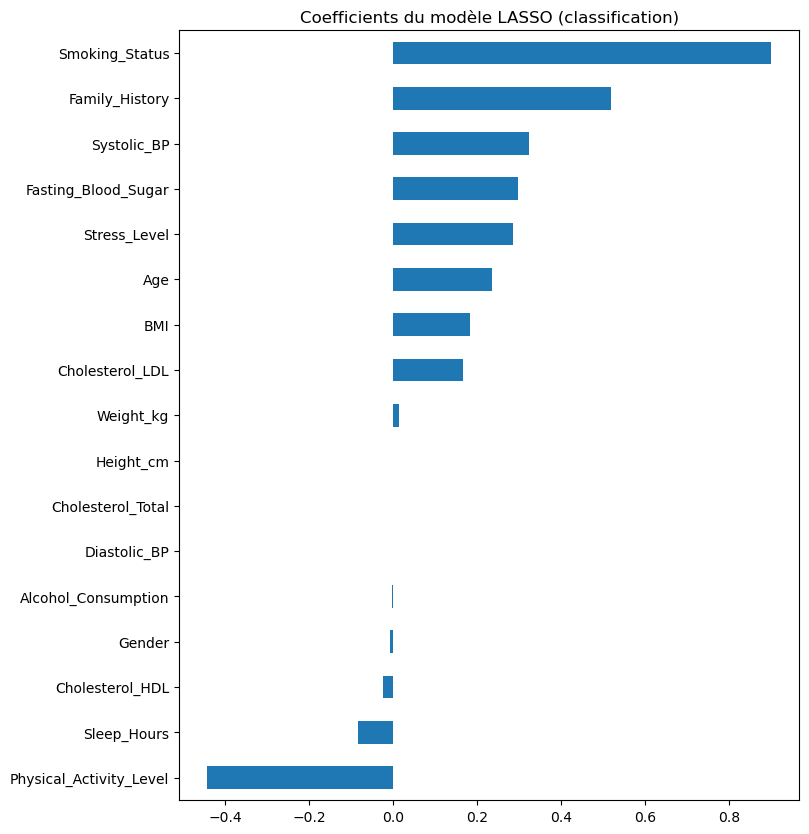

In [21]:
# Coefficients du meilleur modèle
lassoCoef = lassoOpt.best_estimator_.coef_[0]
print(f"Coefficients de LASSO : {lassoCoef}")

coef = pd.Series(lassoCoef, index=X_train_c.columns)

print("\nLasso conserve", sum(coef != 0),
      "variables et en supprime", sum(coef == 0))

# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle LASSO (classification)")
plt.show()

L'affichage des coefficients du modèle LASSO illustre parfaitement le fonctionnement mathématique de la pénalisation L¹. On observe que l'algorithme a écrasé l'impact de certaines variables en fixant leur coefficient à zéro, il a donc fait une sélection de variables.

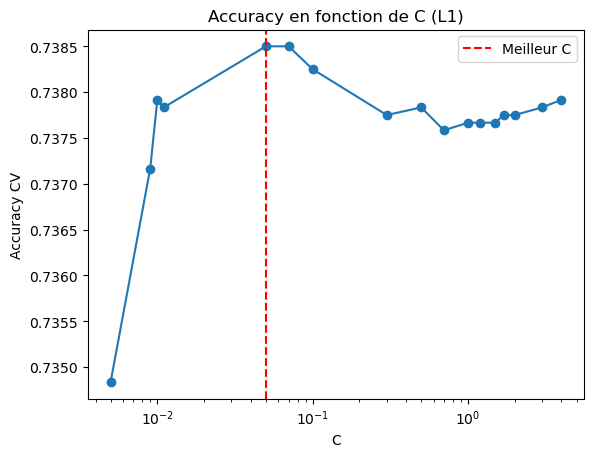

In [22]:
# Affichage de l'accuracy CV en fonction de la valeur de C
mean_scores = lasso.cv_results_['mean_test_score']
Cs = param["C"]

plt.plot(Cs, mean_scores, marker='o')
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy CV")
plt.title("Accuracy en fonction de C (L1)")
plt.axvline(lassoOpt.best_params_['C'], color='red', linestyle='--', label='Meilleur C')
plt.legend()
plt.show()



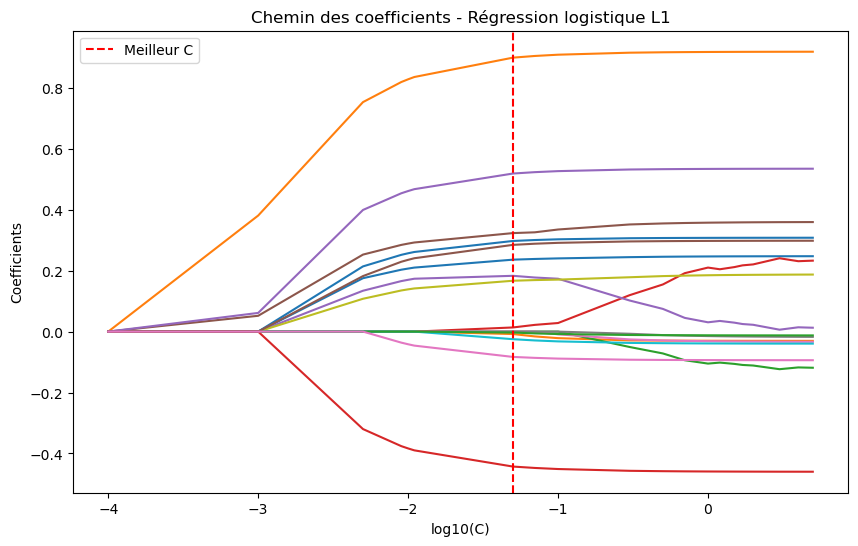

In [23]:
# Nous sommes obligés d'entraîner à nouveau un modèle afin de récupérer les valeurs des coefficients pour chaque C
Cs = [0.0001,0.001,0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4,4.5,5]  #on rajoute 0.0001,0.001, et ,4.5,5 pour la visualisation
coefs = []

for C in Cs:
    clf = LogisticRegression(l1_ratio=1, solver="liblinear", C=C, random_state=42)
    clf.fit(Xr_train_c, y_train_c)
    coefs.append(clf.coef_.ravel())

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
plt.plot(np.log10(Cs), coefs)
plt.xlabel("log10(C)")
plt.ylabel("Coefficients")
plt.title("Chemin des coefficients - Régression logistique L1")
plt.axvline(np.log10(lasso.best_params_['C']), color='red', linestyle='--', label='Meilleur C')
plt.legend()
plt.show()


Pour des valeurs de C très faibles (donc pour une très forte pénalité), tous les coefficients sont nuls. A mesure que C croît, les coefficients des variables grandissent jusqu'à se stabiliser autour d'une certaine valeur pour certains. Nous remarquons que certains coefficients sont restés nuls, ce qui est cohérent puisque LASSO fait une sélection de variables.

#### I. d) Elastic Net

In [24]:
# Grille d'hyperparamètres (C = 1/λ)
param = {"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4], "l1_ratio":[0.1,0.3,0.5,0.6,0.8,0.85,0.9,0.95]}

ela = GridSearchCV(LogisticRegression(solver="saga", random_state=42),param,cv=5,n_jobs=-1)

elaOpt = ela.fit(Xr_train_c, y_train_c)

In [25]:
# Prédictions
y_pred_ela = elaOpt.best_estimator_.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_ela,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (Elastic Net): {elaOpt.best_params_}")
print(f"Accuracy CV (train, Elastic Net): {elaOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Elastic Net) : {accuracy_score(y_test_c, y_pred_ela)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_ela)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_ela)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1375,317
Risque (1),466,842


Meilleurs hyperparamètres (Elastic Net): {'C': 0.05, 'l1_ratio': 0.85}
Accuracy CV (train, Elastic Net): 73.9083%
Accuracy globale (test, Elastic Net) : 73.9000%
Rappel (Détection vrais malades) : 64.3731%
Précision (Fiabilité des alertes) : 72.6488%


Combiner les pénalités L¹ et L² grâce à Elastic Net aboutit en un classificateur qui a une **performance globale** de 73.9%, ce qui est moins bien que celle obtenue par le modèle LASSO.
Nous remarquons là encore que le **rappel** (la détection des vrais malades) est plus faible que la **précision** (la fiabilité des alertes): 64.37% contre 72.65%. 

Nous remarquons une légère amélioration de la précision par rapport à LASSO: 72.65% contre 72.62%. Concrètement, le modèle Elastic Net génère 2 fausses alertes (Faux Positifs) de moins que LASSO. Cependant, nous observons une nette dégradation du rappel par rapport au modèle LASSO. En effet, le nombre de Faux Négatifs est de à 466, contre 462 pour LASSO. Concrètement le modèle Elastic Net n'a pas détecté 4 malades de plus que le modèle LASSO.

Enfin, nous remarquons que le modèle optimal Elastic Net se comporte à 85% comme le modèle LASSO (l1_ratio). Cela confirme que pour nos données, l'approche par sélection de variables est la plus pertinente. Cette cohérence est d'ailleurs illustrée par le fait que les coefficients annulés par l'Elastic Net sont identiques à ceux identifiés par le LASSO.

Coefficients de Elastic Net : [ 0.23728764 -0.01215111  0.          0.01824738  0.18008817  0.32446839
  0.          0.          0.16804975 -0.02705931  0.29897499  0.90070544
 -0.00453408 -0.44490716  0.52022995  0.28640507 -0.08464795]

Elastic Net conserve 14 variables et en supprime 3


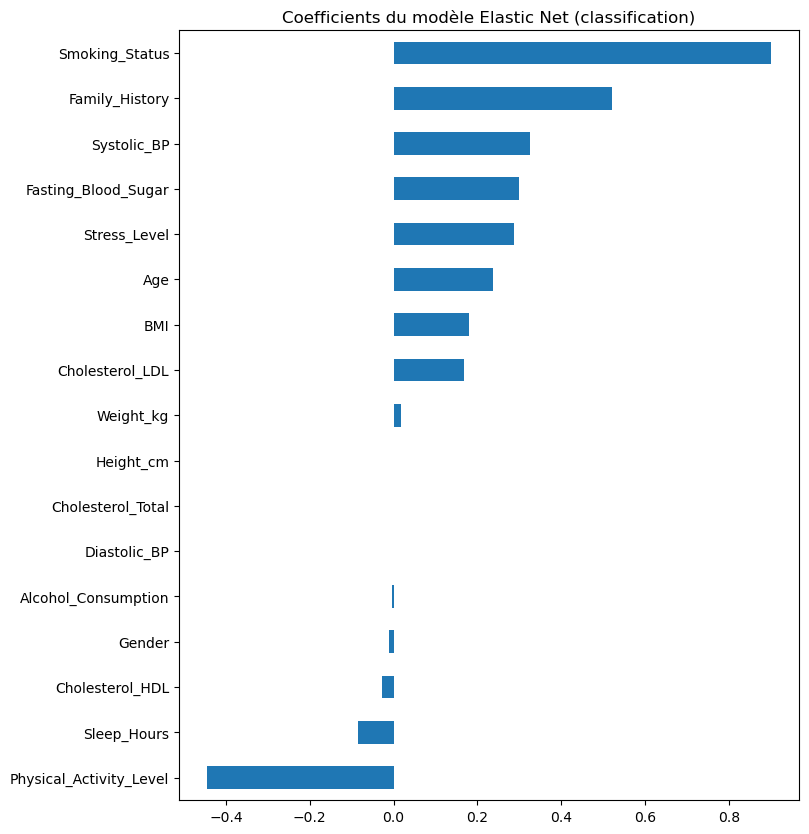

In [26]:
# Coefficients du meilleur modèle
elaCoef = elaOpt.best_estimator_.coef_[0]
print(f"Coefficients de Elastic Net : {elaCoef}")

coef = pd.Series(elaCoef, index=X_train_c.columns)

print("\nElastic Net conserve", sum(coef != 0),
      "variables et en supprime", sum(coef == 0))


# Visualisation
imp_coef = coef.sort_values()
plt.figure(figsize=(8,10))
imp_coef.plot(kind="barh")
plt.title("Coefficients du modèle Elastic Net (classification)")
plt.show()

### II. Support Vector

Pour la tâche de classification, nous ne pouvons utiliser que SVC et non SVR. Nous testons tous les noyaux disponibles.

#### II. a) SVM avec kernel RBF

In [27]:
from sklearn.svm import SVC

param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm= GridSearchCV(SVC(kernel="rbf", random_state=42),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xr_train_c, y_train_c)

In [28]:
# Prédictions
y_pred_rbf = svmOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_rbf,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM RBF): {svmOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM RBF): {svmOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM RBF) : {accuracy_score(y_test_c, y_pred_rbf)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_rbf)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_rbf)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1384,308
Risque (1),493,815


Meilleur C (SVM RBF): 0.7
Accuracy CV (train, SVM RBF): 72.9417%
Accuracy globale (test, SVM RBF) : 73.3000%
Rappel (Détection vrais malades) : 62.3089%
Précision (Fiabilité des alertes) : 72.5735%


#### II. b) SVM avec kernel linéaire

In [29]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_l= GridSearchCV(SVC(kernel="linear", random_state=42),param,cv=10,n_jobs=-1)
svm_lOpt=svm_l.fit(Xr_train_c, y_train_c)

In [30]:
# Prédictions
y_pred_l = svm_lOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_l,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM Linéaire): {svm_lOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Linéaire): {svm_lOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM Linéaire) : {accuracy_score(y_test_c, y_pred_l)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_l)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_l)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1361,331
Risque (1),492,816


Meilleur C (SVM Linéaire): 0.3
Accuracy CV (train, SVM Linéaire): 73.2167%
Accuracy globale (test, SVM Linéaire) : 72.5667%
Rappel (Détection vrais malades) : 62.3853%
Précision (Fiabilité des alertes) : 71.1421%


#### II. c) SVM avec kernel polynomial

In [31]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_p= GridSearchCV(SVC(kernel="poly", random_state=42),param,cv=10,n_jobs=-1)
svm_pOpt=svm_p.fit(Xr_train_c, y_train_c)

In [32]:
# Prédictions
y_pred_p = svm_pOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_p,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM Polynomial): {svm_pOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Polynomial): {svm_pOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM Polynomial) : {accuracy_score(y_test_c, y_pred_p)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_p)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_p)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1409,283
Risque (1),549,759


Meilleur C (SVM Polynomial): 0.3
Accuracy CV (train, SVM Polynomial): 73.1667%
Accuracy globale (test, SVM Polynomial) : 72.2667%
Rappel (Détection vrais malades) : 58.0275%
Précision (Fiabilité des alertes) : 72.8407%


#### II. d) SVM avec kernel sigmoid

In [33]:
param=[{"C":[0.005,0.009,0.01,0.011,0.05,0.07,0.1,0.3,0.5,0.7,1,1.2,1.5,1.7,2,3,4]}]
svm_s= GridSearchCV(SVC(kernel="sigmoid", random_state=42),param,cv=10,n_jobs=-1)
svm_sOpt=svm_s.fit(Xr_train_c, y_train_c)

In [34]:
# Prédictions
y_pred_s = svm_sOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_s,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleur C (SVM Sigmoid): {svm_sOpt.best_params_['C']}")
print(f"Accuracy CV (train, SVM Sigmoid): {svm_sOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, SVM Sigmoid) : {accuracy_score(y_test_c, y_pred_s)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_s)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_s)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1407,285
Risque (1),541,767


Meilleur C (SVM Sigmoid): 0.011
Accuracy CV (train, SVM Sigmoid): 73.0083%
Accuracy globale (test, SVM Sigmoid) : 72.4667%
Rappel (Détection vrais malades) : 58.6391%
Précision (Fiabilité des alertes) : 72.9087%


Nous remarquons que les résulats obtenus par les SVM sont très différents selon le type de noyau utilisé. En effet, le noyau qui donne la meilleure **performance globale** est le RBF avec 73.3%, le noyau Linéaire est le deuxième avec 72.57% ; le noyau Polynomial est à 72.27% et le noyau Sigmoid à 72.47%. Bien que ces résultats semblent tous bons, nous remarquons une réelle différence entre les noyaux lorsque nous regardons le rappel de chaque modèle.

En effet, lorsque le noyau est complexe (Polynomial et Sigmoid), le **rappel** chute grandement (58.03% et 58.64% respectivement). Au contraire, les noyaux plus simples (RBF et Linéaire) donne des rappels bien meilleurs : 62.31% et 62.37% respectivement. Ces observations semblent donc indiquer que la relation entre les variables explicatives et la variable de risque de maladie cardiaque est plutôt linéaire. Cela expliquerait aussi pourquoi les modèles linéaires obtiennent d'aussi bons résultats.

Finalement, nous remarquons que le modèle LASSO reste le meilleur modèle avec son rappel de 64.68%.

### III. Arbre optimal, Random Forest, Boosting

#### III. a) Arbre optimal

In [35]:
from sklearn.tree import DecisionTreeClassifier

# Optimisation de la profondeur de l'arbre
param={"max_depth": list(range(2,15)), "criterion": ["gini", "entropy"], "min_samples_leaf": list(range(2,6))}
tree= GridSearchCV(DecisionTreeClassifier(random_state=42),param,cv=10,n_jobs=-1)
treeOpt=tree.fit(Xr_train_c, y_train_c)

In [36]:
# Prédictions
y_pred_t = treeOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_t,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (Arbre): {treeOpt.best_params_}")
print(f"Accuracy CV (train, Arbre): {treeOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Arbre) : {accuracy_score(y_test_c, y_pred_t)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_t)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_t)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1358,334
Risque (1),557,751


Meilleurs hyperparamètres (Arbre): {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4}
Accuracy CV (train, Arbre): 71.5250%
Accuracy globale (test, Arbre) : 70.3000%
Rappel (Détection vrais malades) : 57.4159%
Précision (Fiabilité des alertes) : 69.2166%


L'entraînement d'un arbre de décision optimal aboutit en un classificateur qui a une **performance globale** de 70.3%. C'est un bon score, mais il reste inférieur à ceux obtenus par nos modèles linéaires.
Nous remarquons surtout que le **rappel** (la détection des vrais malades) s'effondre à 57.42%, ce qui est beaucoup trop faible dans un cadre médical. De plus, la **précision** (la fiabilité des alertes) chute également à 69.22%. Concrètement, notre modèle génère 557 Faux Négatifs, ce qui n'est absolument pas satisfaisant dans un contexte médical. 

L'arbre optimal est donc actuellement le pire modèle de notre étude en termes de performances. Cela peut indiquer que les relations entre les variables et le risque de maladie sont plutôt linéaires et continues. L'approche par seuils successifs de l'arbre n'arrive donc pas à bien les modéliser.

De plus, le modèle a dû créer des régles très complexes pour tenter de s'adapter, au point que l'arbre final en devient illisible s'il est affiché dans sa totalité.

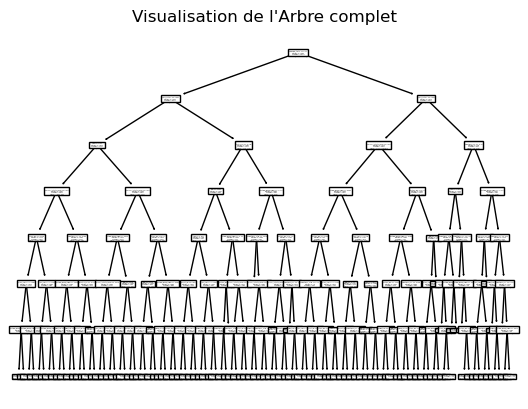

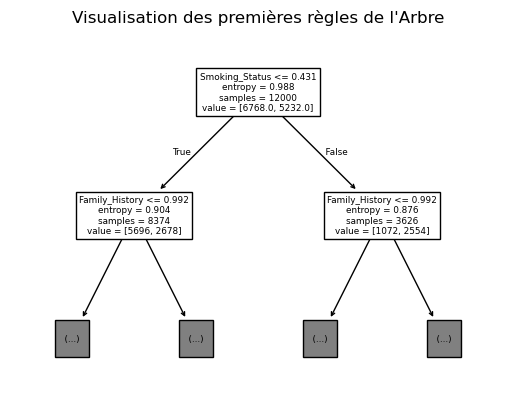

In [37]:
from sklearn.tree import plot_tree

# Affichage de l'arbre entier
plot_tree(treeOpt.best_estimator_,feature_names=df_cls.columns.tolist())
plt.title("Visualisation de l'Arbre complet")
plt.show()


# Affichage du début de l'arbre
plot_tree(treeOpt.best_estimator_,feature_names=df_cls.columns.tolist(), max_depth=1)
plt.title("Visualisation des premières règles de l'Arbre")
plt.show()

#### III. b) Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier 

# Hyperparamères
param_rf = {'n_estimators':[50,100,300], 'max_features': ['sqrt', 'log2'], 'max_depth': [5, 10], 'min_samples_leaf':[2,3,4,5]}
rf= GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=42),param,cv=10,n_jobs=-1)
rfOpt=rf.fit(Xr_train_c, y_train_c)

In [39]:
# Prédictions
y_pred_rf = rfOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_rf,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (RF): {rfOpt.best_params_}")
print(f"Accuracy CV (train, RF): {rfOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, RF) : {accuracy_score(y_test_c, y_pred_rf)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_rf)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_rf)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1383,309
Risque (1),497,811


Meilleurs hyperparamètres (RF): {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 4}
Accuracy CV (train, RF): 73.1917%
Accuracy globale (test, RF) : 73.1333%
Rappel (Détection vrais malades) : 62.0031%
Précision (Fiabilité des alertes) : 72.4107%


L'algorithme Random Forest offre des résultats nettement supérieurs à ceux d'un arbre simple (CART), avec une **performance globale** de 73.13%. Son **rappel** atteint 62% et sa **précision** de 72.41%, ce qui en fait donc un bon modèle par rapport à l'Arbre seul et aux SVM avec un noyau Polynomial ou Sigmoid, mais il est tout de même nettement moins bon que les modèles linéaires en termes de rappel.

En effet, Random Forest génère 497 Faux Négatifs, ce qui est énorme pour notre contexte médical. En fait, il semblerait que ce modèle ait d'aussi bon score car il est conservateur: il préfère prédire Sain(0) plutôt que Risque(1) s'il y a un doute. En effet, le nombre de Vrais Négatifs est bien supérieur aux résultats des autres modèles.

Smoking_Status 0.1707727832043547
Fasting_Blood_Sugar 0.07716729951240517
Systolic_BP 0.07705132495100277
Age 0.07023189021183728
BMI 0.06749556997586871
Weight_kg 0.06606920399883215
Cholesterol_LDL 0.061439919892064154
Cholesterol_Total 0.061403861762567284
Height_cm 0.06005132965514643
Diastolic_BP 0.05373214480879715
Family_History 0.05303523590376213
Stress_Level 0.04761625196439285
Physical_Activity_Level 0.04631055925275049
Cholesterol_HDL 0.044571835770489926
Sleep_Hours 0.023294915160121124
Alcohol_Consumption 0.013280505737453117
Gender 0.006475368238154569


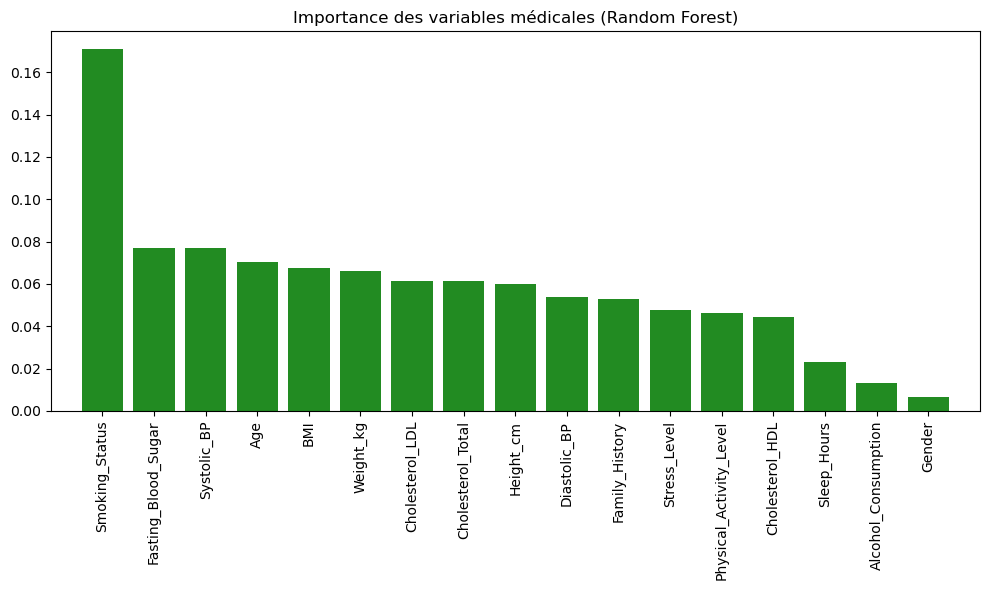

In [40]:
# Importance décroissante des variables
importances = rfOpt.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(Xr_train_c.shape[1]):
    print(df_cls.columns[indices[f]], importances[indices[f]])

plt.figure(figsize=(10, 6)) # Un peu plus large pour que les mots respirent
plt.title("Importance des variables médicales (Random Forest)")
plt.bar(range(Xr_train_c.shape[1]), importances[indices], color="forestgreen")

noms_variables = [df_cls.columns[i] for i in indices]
plt.xticks(range(Xr_train_c.shape[1]), noms_variables, rotation=90)

plt.xlim([-1, Xr_train_c.shape[1]])
plt.tight_layout() # Empêche les mots d'être coupés en bas de l'image
plt.show()


Nous remarquons que la variable 'Smoking_Status' a une importance prédominante pour le risque de maladie cardiaque dans ce modèle Random Forest. Nous avons précédemment retrouvé ce résultat avec les modèles Ridge, LASSO et Elastic Net. En effet, cette variable a le plus grand coefficient dans ces 3 modèles.

Nous remarquons cependant que la deuxième variable la plus importante de ce modèle, 'Fasting_Blood_Sugar' ne correspond qu'à une variable qui a un coefficient moyen pour LASSO, Ridge et Elastic Net. Cette différence peut être expliquée par la nature même des algorithmes. En effet, les modèles comme LASSO cherchent des relations purement linéaires, alors que Random Forest est capable de détecter des effets de seuil (non-linéaires donc). Ce phénomène est très marqué pour la glycémie.

#### III. c) Boosting

In [41]:
#Boosting
from sklearn.ensemble import GradientBoostingClassifier

param = {"n_estimators": [50, 100, 200], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]}
gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param, cv=5, n_jobs=-1, verbose=1)
gbOpt = gb.fit(Xr_train_c, y_train_c)


Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [42]:
# Prédictions
y_pred_gb = gbOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_gb,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (Boosting): {gbOpt.best_params_}")
print(f"Accuracy CV (train, Boosting): {gbOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, Boosting) : {accuracy_score(y_test_c, y_pred_gb)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_gb)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_gb)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1368,324
Risque (1),494,814


Meilleurs hyperparamètres (Boosting): {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Accuracy CV (train, Boosting): 73.6250%
Accuracy globale (test, Boosting) : 72.7333%
Rappel (Détection vrais malades) : 62.2324%
Précision (Fiabilité des alertes) : 71.5290%


Contrairement à la Forêt Aléatoire, le Gradient  Boosting classique n'adopte pas un comportement conservateur : il détecte moins de Vrais Négatifs (1368) et prend davantage le risque de classer les cas ambigus en Risque(1), ce qui génère 324 Faux Positifs. Toutefois, cette tentative risquée n'est pas récompensée. En effet, malgré un **rappel** de 62.23%, ce modèle laisse passer 494 malades (Faux Négatifs). Ce n'est donc pas une bonne performance dans le secteur médical.

In [43]:
#XGBoosting
from xgboost import XGBClassifier

param = {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]}
xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42), param, cv=5, n_jobs=-1)
xgbOpt = xgb.fit(Xr_train_c, y_train_c)


In [44]:
# Prédictions
y_pred_xgb = xgbOpt.predict(Xr_test_c)

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_xgb,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleurs hyperparamètres (XGBoosting): {xgbOpt.best_params_}")
print(f"Accuracy CV (train, XGBoosting): {xgbOpt.best_score_*100:.4f}%")
print(f"Accuracy globale (test, XGBoosting) : {accuracy_score(y_test_c, y_pred_xgb)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_xgb)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_xgb)*100:.4f}%")

Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1358,334
Risque (1),474,834


Meilleurs hyperparamètres (XGBoosting): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy CV (train, XGBoosting): 73.4417%
Accuracy globale (test, XGBoosting) : 73.0667%
Rappel (Détection vrais malades) : 63.7615%
Précision (Fiabilité des alertes) : 71.4041%


L'algorithme XGBoosting accentue encore cette prise de risque : il diminue encore son nombre de Sain(0). Cependant, cette prise de risque est mieux récompensée que pour le Boosting classique : le XGBoosting détecte 20 malades de plus que ce dernier, amenant alors son **rappel** à 63.76%.

Finalement, malgré ce bon score, cet algorithme pourtant réputé pour sa puissance ne parvient pas à battre notre modèle LASSO quant au rappel.

### IV. Neural Networks

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)


n_features = Xr_train_c.shape[1]
n_classes = 2


I0000 00:00:1779108309.590652  323280 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [56]:
# Nous testons d'abord une architecture très simple : une seule couche cachée. 
# Nous cherchons le nombre optimal de neurones dans cette couche
hidden_list = range(1, 10)
scores_1_couche = []

for n_hidden in hidden_list:
    accuracies = []
    recalls = []
    
    for i in range(5):
        keras_model = Sequential()
        keras_model.add(Dense(n_hidden, input_dim=n_features, activation='sigmoid'))
        keras_model.add(Dense(1, activation='sigmoid'))

        keras_model.compile(optimizer=SGD(learning_rate=0.3), loss='binary_crossentropy')

        # Entraînement
        keras_model.fit(Xr_train_c, y_train_c, epochs=15, batch_size=32, verbose=0)

        # Prédictions
        y_pred_prob = keras_model.predict(Xr_test_c, verbose=0)
        y_pred_classes = (y_pred_prob > 0.5).astype(int)

        # Calcul
        acc = accuracy_score(y_test_c, y_pred_classes)
        rec = recall_score(y_test_c, y_pred_classes)
        
        accuracies.append(acc)
        recalls.append(rec)

    mean_acc = np.mean(accuracies)
    mean_rec = np.mean(recalls)
    
    scores_1_couche.append({'n_hidden': n_hidden, 'acc': mean_acc, 'rec': mean_rec})
    print(f"{n_hidden} neurones -> Accuracy: {mean_acc*100:.2f}% | Rappel: {mean_rec*100:.2f}%")

# On extrait automatiquement le meilleur nombre de neurones pour le rappel
meilleur_choix_acc = max(scores_1_couche, key=lambda x: x['acc'])
meilleur_choix_rap = max(scores_1_couche, key=lambda x: x['rec'])
n_hidden_best_rap = meilleur_choix_rap['n_hidden']
n_hidden_best_acc = meilleur_choix_acc['n_hidden']

print(f"\n=> Le meilleur nombre de neurones retenu pour la suite est : {n_hidden_best_rap} pour le rappel et {n_hidden_best_acc} pour l'accuracy")


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

1 neurones -> Accuracy: 72.55% | Rappel: 66.90%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

2 neurones -> Accuracy: 72.89% | Rappel: 66.80%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

...

7 neurones -> Accuracy: 72.92% | Rappel: 67.26%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

8 neurones -> Accuracy: 73.15% | Rappel: 67.49%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

9 neurones -> Accuracy: 72.96% | Rappel: 67.54%

=> Le meilleur nombre de neurones retenu pour la suite est : 9 pour le rappel et 8 pour l'accuracy


In [57]:
# Nous cherchons maintenant à savoir si ajouter des couches permet d'obtenir de meilleurs scores
architectures_a_tester = [(n_hidden_best_rap,), (n_hidden_best_acc,), (n_hidden_best_acc, 5), (n_hidden_best_rap, 5)]

scores_finaux = []

for plan in architectures_a_tester:
    accuracies = []
    recalls = []
    
    for i in range(5):
        keras_model = Sequential()
        
        keras_model.add(Dense(plan[0], input_dim=n_features, activation='sigmoid'))
        
        # Si le tuple contient plus d'un élément, on ajoute les couches suivantes
        if len(plan) > 1:
            for nb_neurones in plan[1:]:
                keras_model.add(Dense(nb_neurones, activation='sigmoid'))
                
        keras_model.add(Dense(1, activation='sigmoid'))
        
        # Compilation & Entraînement
        keras_model.compile(optimizer=SGD(learning_rate=0.3), loss='binary_crossentropy')
        keras_model.fit(Xr_train_c, y_train_c, epochs=15, batch_size=32, verbose=0)
        
        # Prédictions
        y_pred_prob = keras_model.predict(Xr_test_c, verbose=0)
        y_pred_classes = (y_pred_prob > 0.5).astype(int)
        
        # Calcul des métriques
        acc = accuracy_score(y_test_c, y_pred_classes)
        rec = recall_score(y_test_c, y_pred_classes)
        
        accuracies.append(acc)
        recalls.append(rec)

    # Moyennes pour cette architecture
    mean_acc = np.mean(accuracies)
    mean_rec = np.mean(recalls)
    
    scores_finaux.append({'plan': plan, 'acc': mean_acc, 'rec': mean_rec})
    print(f"Architecture {plan} -> Accuracy: {mean_acc*100:.2f}% | Rappel: {mean_rec*100:.2f}%")


meilleur_plan_acc = max(scores_finaux, key=lambda x: x['acc'])
meilleur_plan_rec = max(scores_finaux, key=lambda x: x['rec'])

print("\n--- RÉSULTATS FINAUX ---")
print(f"Meilleure architecture pour l'accuracy : {meilleur_plan_acc['plan']} (Score: {meilleur_plan_acc['acc']*100:.2f}%)")
print(f"Meilleure architecture pour le rappel  : {meilleur_plan_rec['plan']} (Score: {meilleur_plan_rec['rec']*100:.2f}%)")

/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Architecture (9,) -> Accuracy: 72.77% | Rappel: 67.66%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Architecture (8,) -> Accuracy: 72.78% | Rappel: 67.55%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Architecture (8, 5) -> Accuracy: 73.01% | Rappel: 67.84%


/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Architecture (9, 5) -> Accuracy: 72.87% | Rappel: 67.87%

--- RÉSULTATS FINAUX ---
Meilleure architecture pour l'accuracy : (8, 5) (Score: 73.01%)
Meilleure architecture pour le rappel  : (9, 5) (Score: 67.87%)


In [58]:
# Entraînement des MLP
# Meilleur rappel
mlp_rec = Sequential()
plan_rec = meilleur_plan_rec['plan']
mlp_rec.add(Dense(plan_rec[0], input_dim=n_features, activation='sigmoid'))
if len(plan_rec) > 1:
    for n in plan_rec[1:]:
        mlp_rec.add(Dense(n, activation='sigmoid'))
mlp_rec.add(Dense(1, activation='sigmoid'))
mlp_rec.compile(optimizer=SGD(learning_rate=0.3), loss='binary_crossentropy')
mlp_rec.fit(Xr_train_c, y_train_c, epochs=15, batch_size=32, verbose=0)

# Meilleur accuracy
mlp_acc = Sequential()
plan_acc = meilleur_plan_acc['plan']
mlp_acc.add(Dense(plan_acc[0], input_dim=n_features, activation='sigmoid'))
if len(plan_acc) > 1:
    for n in plan_acc[1:]:
        mlp_acc.add(Dense(n, activation='sigmoid'))
mlp_acc.add(Dense(1, activation='sigmoid'))
mlp_acc.compile(optimizer=SGD(learning_rate=0.3), loss='binary_crossentropy')
mlp_acc.fit(Xr_train_c, y_train_c, epochs=15, batch_size=32, verbose=0)

/home/astrid/anaconda3/envs/ML/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
# Prédictions
print("--------- Meilleure accuracy -----------\n")
y_pred_acc = (mlp_acc.predict(Xr_test_c, verbose=0)> 0.5).astype(int).flatten()

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_acc,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleure architecture (MLP): {meilleur_plan_acc['plan']}")
print(f"Accurracy moyenne CV (train, MLP) : {meilleur_plan_acc['acc']*100:.4f}%")
print(f"Accuracy globale (test, MLP) : {accuracy_score(y_test_c, y_pred_acc)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_acc)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_acc)*100:.4f}%")



print("\n--------- Meilleur rappel -----------\n")
# Prédictions
y_pred_rap = (mlp_rec.predict(Xr_test_c, verbose=0) > 0.5).astype(int).flatten()

# Table de résultats
table = pd.crosstab(y_test_c, y_pred_rap,rownames=['Réalité'],colnames=['Prédiction']) # Création de la matrice de confusion
table.index = ["Sain (0)", "Risque (1)"]
table.columns = ["Sain (0)", "Risque (1)"]
table.index.name = "Réalité"
table.columns.name = "Prédiction"
display(table)

print(f"Meilleure architecture (MLP): {meilleur_plan_rec['plan']}")
print(f"Accuracy moyenne CV (train, MLP) : {meilleur_plan_rec['acc']*100:.4f}%")
print(f"Accuracy globale (test, MLP) : {accuracy_score(y_test_c, y_pred_rap)*100:.4f}%")
print(f"Rappel (Détection vrais malades) : {recall_score(y_test_c, y_pred_rap)*100:.4f}%")
print(f"Précision (Fiabilité des alertes) : {precision_score(y_test_c, y_pred_rap)*100:.4f}%")

--------- Meilleure accuracy -----------



Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1293,399
Risque (1),413,895


Meilleure architecture (MLP): (8, 5)
Accurracy moyenne CV (train, MLP) : 73.0133%
Accuracy globale (test, MLP) : 72.9333%
Rappel (Détection vrais malades) : 68.4251%
Précision (Fiabilité des alertes) : 69.1654%

--------- Meilleur rappel -----------



Prédiction,Sain (0),Risque (1)
Réalité,,
Sain (0),1307,385
Risque (1),421,887


Meilleure architecture (MLP): (9, 5)
Accuracy moyenne CV (train, MLP) : 72.8733%
Accuracy globale (test, MLP) : 73.1333%
Rappel (Détection vrais malades) : 67.8135%
Précision (Fiabilité des alertes) : 69.7327%


Nous avons commencé par trouver le nombre de neurones optimal pour un MLP avec une seule couche cachée. Nous avons ensuite cherché à rajouter une couche afin de voir si cela pouvait améliorer les résultats. Finalement, nous avons retenu 2 modèles : celui qui donne la meilleure performance globale et celui qui a le meilleur rappel.

Malgré nos essais de reproductibilité avec Tensorflow, nous ne sommes pas parvenus à obtenir des résultats constants d'une exécution à l'autre. Nous remarquons cependant que la performance globale de nos meilleurs modèles se maintient autour de 73 %, avec un rappel oscillant entre 67% et 69%. Nous pouvons expliquer cette hausse du rappel  par le fait que ces deux MLP ont tendance à prédire un Risque(1) plutôt qu'un Sain(0) dans les cas ambigus. En effet, nous observons un nombre de Faux Positifs plus élevé que pour les autres modèles. Nos MLP appliquent donc le principe de précaution, ce qui constitue un atout majeur pour un outil de dépistage dans le secteur médical.


Finalement, les MLP battent le modèle LASSO quant au rappel. Cela peut être expliqué par le fait qu'un MLP peut à la fois détecter des relations linéaires et non-linéaires entre les variables, ce qui n'est pas le cas de LASSO. Cela permet donc au MLP de "voir" des liens que LASSO rate, par exemple les seuils de glycémie

### V. Comparaison des modèles

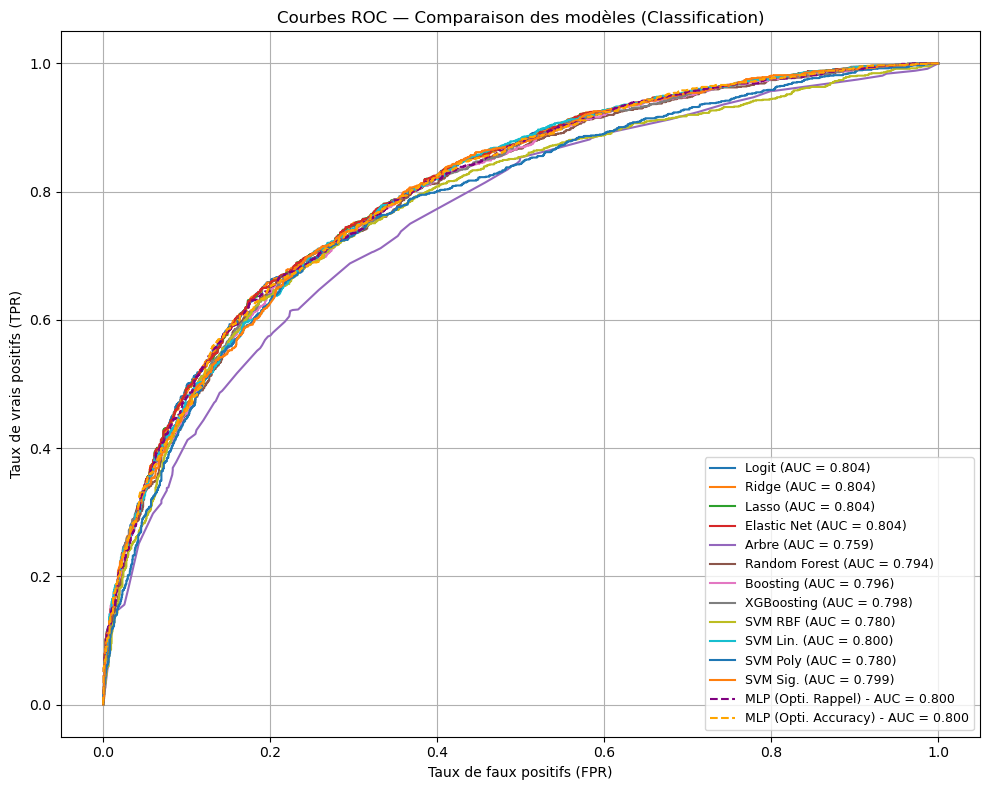

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

#Models that directly give predict_proba : LogisticRegression, Ridge, Lasso, ElasticNet, RandomForest, DecisionTree

models_proba = {
    "Logit":        logitOpt,
    "Ridge":        ridgeOpt.best_estimator_,
    "Lasso":        lassoOpt.best_estimator_,
    "Elastic Net":  elaOpt.best_estimator_,
    "Arbre":        treeOpt.best_estimator_,
    "Random Forest": rfOpt.best_estimator_,
    "Boosting":     gbOpt.best_estimator_,
    "XGBoosting":     xgbOpt.best_estimator_
}

#SVM: besoin de refit avec probability=True
svm_rbf_prob  = SVC(kernel="rbf",     C=svmOpt.best_params_['C'],     probability=True, random_state=42)
svm_lin_prob  = SVC(kernel="linear",  C=svm_lOpt.best_params_['C'],   probability=True, random_state=42)
svm_poly_prob = SVC(kernel="poly",    C=svm_pOpt.best_params_['C'],   probability=True, random_state=42)
svm_sig_prob  = SVC(kernel="sigmoid", C=svm_sOpt.best_params_['C'],   probability=True, random_state=42)

for name, m in [("SVM RBF", svm_rbf_prob), ("SVM Lin.", svm_lin_prob),
                ("SVM Poly", svm_poly_prob), ("SVM Sig.", svm_sig_prob)]:
    m.fit(Xr_train_c, y_train_c)
    models_proba[name] = m

#PLot
plt.figure(figsize=(10, 8))

for name, model in models_proba.items():
    probs = model.predict_proba(Xr_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Neural networks
# Meilleur Rappel
probs_mlp_rec = mlp_rec.predict(Xr_test_c, verbose=0)[:, 0].flatten()
fpr_nr, tpr_nr, _ = roc_curve(y_test_c, probs_mlp_rec)
plt.plot(fpr_nr, tpr_nr, label=f"MLP (Opti. Rappel) - AUC = {auc(fpr_nr, tpr_nr):.3f}", linestyle='--', color='purple')

# Meilleur Accuracy
probs_mlp_acc = mlp_acc.predict(Xr_test_c, verbose=0)[:, 0].flatten()
fpr_na, tpr_na, _ = roc_curve(y_test_c, probs_mlp_acc)
plt.plot(fpr_na, tpr_na, label=f"MLP (Opti. Accuracy) - AUC = {auc(fpr_na, tpr_na):.3f}", linestyle='--', color='orange')


plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC — Comparaison des modèles (Classification)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()




En observant ces courbes ROC, nous remarquons que les meilleurs modèles en termes d'aire sous la courbe sont essentiellemnt les modèles linéaires et les MLP. Si nous rajoutons des contraintes d'interprétabilité, le meilleur modèle est LASSO. Il est effectivement l'un des meilleurs modèles que nous ayons obtenu lors de cette étude et il est aisément compréhensible. En effet, son principe de sélection de variables et le fait que c'est un modèle linéaire le rend très interprétable, ce qui est essentiel dans le secteur médical.

## B. Modeles de regression pour la variable 'Cholesterol_LDL'

Nous nous intéressons maintenant à la prédiction de la variable `Cholesterol_LDL` (le "mauvais" cholestérol) à partir de toutes les autres variables, à l'exception de `Heart_Disease_Risk`. Il s'agit cette fois d'un problème de **régression** : la variable cible est continue. Nous évaluons les modèles avec deux métriques complémentaires : le **R²** (part de variance expliquée, entre 0 et 1, plus c'est élevé mieux c'est) et le **RMSE** (erreur quadratique moyenne, en mg/dL, plus c'est faible mieux c'est).

### I. Modèles linéaires

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet   #On importe des régresseurs qui existent deja
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#pas de reg log car c'est pas de la classif mais de la reg que l'on fait

param = {"alpha": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20]}

# Ridge
ridge_r = GridSearchCV(Ridge(), param, cv=5, n_jobs=-1)
ridge_r.fit(Xr_train_r, y_train_r)
prev = ridge_r.predict(Xr_test_r)
print("RIDGE")
print(f"Meilleur alpha (Ridge): {ridge_r.best_params_['alpha']}")
print(f"MSE = {mean_squared_error(y_test_r, prev):.4f}")
print(f"R²  = {r2_score(y_test_r, prev):.4f}")
print("\n")

# Lasso
lasso_r = GridSearchCV(Lasso(), param, cv=5, n_jobs=-1)
lasso_r.fit(Xr_train_r, y_train_r)
prev = lasso_r.predict(Xr_test_r)
print("Lasso")
print(f"Meilleur alpha (Lasso): {lasso_r.best_params_['alpha']}")
print(f"MSE = {mean_squared_error(y_test_r, prev):.4f}")
print(f"R²  = {r2_score(y_test_r, prev):.4f}")
print("\n")

# ElasticNet
param_ela = {"alpha": [0.01, 0.1, 1, 5], "l1_ratio": [0.2, 0.5, 0.8]}
ela_r = GridSearchCV(ElasticNet(), param_ela, cv=5, n_jobs=-1)
ela_r.fit(Xr_train_r, y_train_r)
prev = ela_r.predict(Xr_test_r)
print("Elastic Net")
print(f"Meilleur alpha (Elastic Net): {ela_r.best_params_['alpha']}")
print(f"MSE = {mean_squared_error(y_test_r, prev):.4f}")
print(f"R²  = {r2_score(y_test_r, prev):.4f}")

RIDGE
Meilleur alpha (Ridge): 20
MSE = 95.7386
R²  = 0.6944


Lasso
Meilleur alpha (Lasso): 0.1
MSE = 95.7145
R²  = 0.6945


Elastic Net
Meilleur alpha (Elastic Net): 0.01
MSE = 95.7429
R²  = 0.6944


Les trois modèles linéaires pénalisés obtiennent des résultats très proches. Le **LASSO** (alpha = 0.1) est légèrement le meilleur avec un R² de **0.6945** et un RMSE de **9.78 mg/dL**, suivi de très près par Ridge (alpha = 20, R² = 0.6944) et Elastic Net (alpha = 0.01, R² = 0.6944).

Ces résultats indiquent que les modèles linéaires expliquent environ **69\% de la variance** de `Cholesterol_LDL`, ce qui constitue une bonne performance de base. Le faible écart entre les trois méthodes suggère que la régularisation apporte peu d'amélioration supplémentaire, et que les variables explicatives entretiennent une relation globalement **linéaire** avec `Cholesterol_LDL`. Le fort alpha optimal de Ridge (20) confirme cependant la présence de multicolinéarité, déjà observée dans l'analyse exploratoire entre `Cholesterol_Total` et les variables de corpulence.

### II. Support Vector

#### II. a) SVM avec kernel RBF

In [ ]:
from sklearn.svm import SVR

param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_rbf= GridSearchCV(SVR(kernel="rbf"),param,cv=10,n_jobs=-1)
svrOpt_rbf=svr_rbf.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_rbf.best_params_}")
print(f"R² CV (train): {svrOpt_rbf.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 10, 'epsilon': 1.0}
R² CV (train): 0.6588


Le SVR avec noyau **RBF** sélectionne C = 10 et epsilon = 1.0 comme hyperparamètres optimaux. Son R² en validation croisée est de **0.6588**, ce qui est inférieur aux modèles linéaires. Le noyau RBF, bien qu'adapté aux relations non-linéaires complexes, ne parvient pas ici à surpasser les approches plus simples.

#### II. b) SVM avec kernel linéaire

In [ ]:
param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_lin= GridSearchCV(SVR(kernel="linear"),param,cv=10,n_jobs=-1)
svrOpt_lin=svr_lin.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_lin.best_params_}")
print(f"R² CV (train): {svrOpt_lin.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 1, 'epsilon': 1.0}
R² CV (train): 0.6856


Le SVR avec noyau **linéaire** sélectionne C = 1 et epsilon = 1.0. Avec un R² CV de **0.6856**, c'est le meilleur SVR de cette comparaison, et son score se rapproche des modèles linéaires pénalisés. Ce résultat confirme que la relation entre les variables explicatives et `Cholesterol_LDL` est **majoritairement linéaire**, cohérent avec les observations de l'analyse exploratoire.

#### II. c) SVM avec kernel polynomial

In [ ]:
param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_p= GridSearchCV(SVR(kernel="poly"),param,cv=10,n_jobs=-1)
svrOpt_p=svr_p.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_p.best_params_}")
print(f"R² CV (train): {svrOpt_p.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 50, 'epsilon': 1.0}
R² CV (train): 0.6494


Le SVR avec noyau **polynomial** sélectionne C = 50 et epsilon = 1.0. Son R² CV de **0.6494** est le plus faible parmi les SVR testés. La forte valeur de C (= 50) indique que le modèle est peu régularisé : il cherche à minimiser fortement les erreurs d'entraînement, au risque de surapprendre.

#### II. d) SVM avec kernel sigmoid

In [ ]:
param = {'C': [0.1, 1, 10, 50], 'epsilon': [0.1, 0.5, 1.0]}
svr_s= GridSearchCV(SVR(kernel="sigmoid"),param,cv=10,n_jobs=-1)
svrOpt_s=svr_s.fit(Xr_train_r, y_train_r)
# paramètre optimal
print(f"Meilleurs hyperparamètres SVR: {svrOpt_s.best_params_}")
print(f"R² CV (train): {svrOpt_s.best_score_:.4f}")

Meilleurs hyperparamètres SVR: {'C': 0.1, 'epsilon': 0.5}
R² CV (train): 0.6595


Le SVR avec noyau **sigmoïde** sélectionne C = 0.1 et epsilon = 0.5. Son R² CV de **0.6595** est légèrement supérieur au polynomial, mais reste en deçà des noyaux linéaire et RBF.

### III. Arbre optimal, Random Forest, Boosting

#### III. a) Arbre optimal

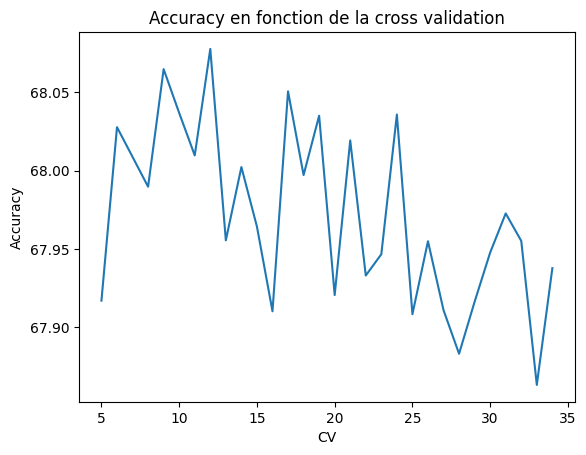

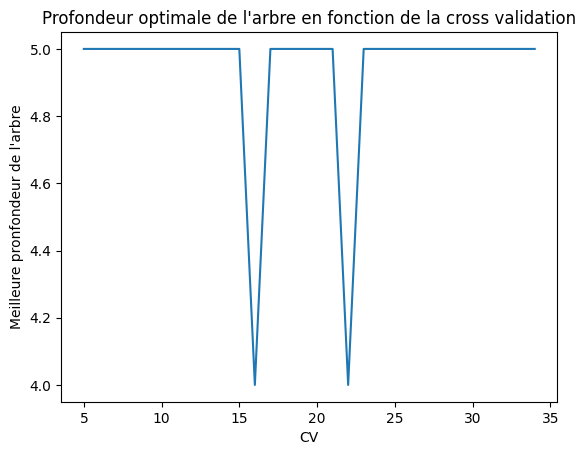

In [83]:
from sklearn.tree import DecisionTreeRegressor
cv_val = []
acc = []
dep = []

for cv in range(5,35):
    cv_val.append(cv)
    # Optimisation de la profondeur de l'arbre
    param=[{"max_depth":list(range(2,15))}]
    tree= GridSearchCV(DecisionTreeRegressor(),param,cv=cv,n_jobs=-1)
    treeOpt=tree.fit(Xr_train_r, y_train_r)
    acc.append(treeOpt.best_score_*100)
    dep.append(treeOpt.best_params_['max_depth'])
    
    #print(f"Meilleure profondeur (Arbre Optimal): {treeOpt.best_params_['max_depth']}")
    #print(f"Accuracy CV (train, Arbre Optimal): {treeOpt.best_score_*100:.4f}%")
plt.plot(cv_val,acc)
plt.xlabel("CV")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de la cross validation")
plt.show()

plt.plot(cv_val,dep)
plt.xlabel("CV")
plt.ylabel("Meilleure pronfondeur de l'arbre")
plt.title("Profondeur optimale de l'arbre en fonction de la cross validation")
plt.show()

L'étude de la profondeur optimale en fonction du nombre de folds montre que la profondeur reste **quasi-constamment à 5** pour des valeurs de cv allant de 5 à 35, avec deux exceptions ponctuelles à 4. Cette stabilité indique que le choix de **cv = 10** est robuste et que la profondeur optimale de 5 est fiable.

In [84]:
# Optimisation de la profondeur de l'arbre
param=[{"max_depth":list(range(2,15))}]
tree= GridSearchCV(DecisionTreeRegressor(),param,cv=10,n_jobs=-1)
treeOpt=tree.fit(Xr_train_r, y_train_r)

    
print(f"Meilleure profondeur (Arbre Optimal): {treeOpt.best_params_['max_depth']}")
print(f"Accuracy CV (train, Arbre Optimal): {treeOpt.best_score_*100:.4f}%")

Meilleure profondeur (Arbre Optimal): 5
Accuracy CV (train, Arbre Optimal): 68.0367%


L'arbre de régression optimal, de profondeur 5, obtient un R² en validation croisée de **68.04%**. Ce résultat est légèrement inférieur aux modèles linéaires, ce qui est cohérent : les arbres de décision capturent des relations par seuils successifs, une approche moins adaptée lorsque la relation sous-jacente est majoritairement linéaire.

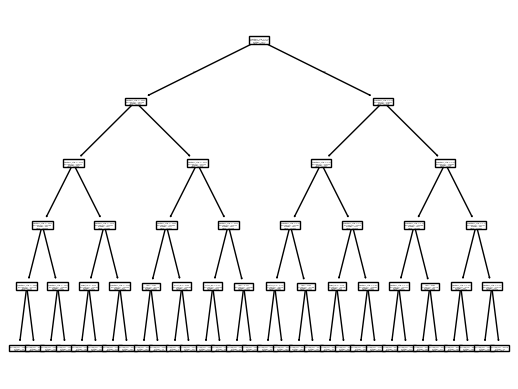

In [85]:
from sklearn.tree import plot_tree

treeG_r=DecisionTreeRegressor(max_depth=treeOpt.best_params_['max_depth'])
treeG_r.fit(Xr_train_r,y_train_r)
plot_tree(treeG_r,feature_names = X_train_r.columns.tolist());
plt.show()

L'arbre affiché dans sa totalité (profondeur 5) est trop dense pour être lisible directement dans le notebook. On peut néanmoins noter que la première division se fait sur `Cholesterol_Total`, confirmant son importance dominante dans la prédiction de `Cholesterol_LDL`.

#### III. b) Random Forest

In [86]:
from sklearn.ensemble import RandomForestRegressor

param=[{"max_features":list(range(2,10,1))}]
rf_r= GridSearchCV(RandomForestRegressor(n_estimators=100),param,cv=10,n_jobs=-1)
rfOpt_r=rf_r.fit(Xr_train_r, y_train_r)

print(f"Meilleure profondeur (Random Forest): {rfOpt_r.best_params_['max_features']}")
print(f"Accuracy CV (train, Random Forest): {rfOpt_r.best_score_*100:.4f}%")

Meilleure profondeur (Random Forest): 8
Accuracy CV (train, Random Forest): 67.0852%


La Forêt Aléatoire sélectionne **max_features = 8** comme hyperparamètre optimal (sur 16 variables), avec un R² en validation croisée de **67.09%**. Ce résultat légèrement inférieur à l'arbre seul en CV s'explique par l'introduction de diversité via le tirage aléatoire de sous-ensembles de variables à chaque nœud, ce qui peut légèrement dégrader les performances en CV tout en améliorant la généralisation sur le jeu de test.

Cholesterol_Total 0.6516370870260527
Age 0.06631036207298209
BMI 0.03675645820179722
Weight_kg 0.033727204950365526
Height_cm 0.03354649344818727
Systolic_BP 0.031130569092179722
Fasting_Blood_Sugar 0.03100724576101786
Diastolic_BP 0.026818291060404953
Cholesterol_HDL 0.02667634814996797
Stress_Level 0.01969857469321964
Sleep_Hours 0.014058442999823326
Physical_Activity_Level 0.010713500698269667
Alcohol_Consumption 0.007100911558552435
Smoking_Status 0.004300464680748974
Family_History 0.0034584148125265095
Gender 0.003059630793904256


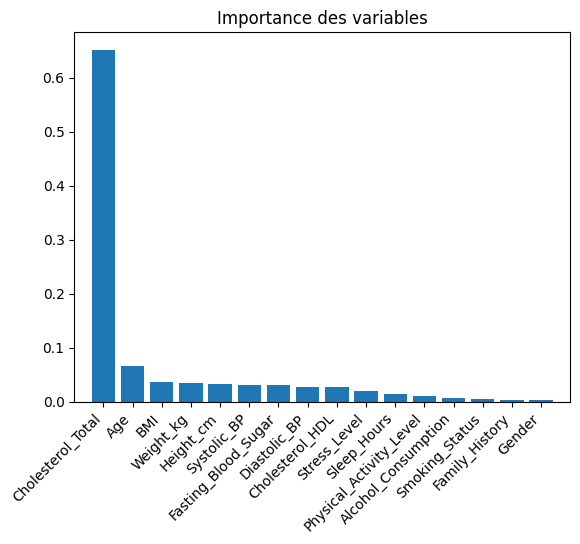

In [87]:
rf = RandomForestRegressor(n_estimators=100, max_features=rfOpt_r.best_params_['max_features'])
rfFit=rf.fit(Xr_train_r, y_train_r)
# Importance décroissante des variables
importances = rfFit.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(Xr_train_r.shape[1]):
    print(X_train_r.columns.tolist()[indices[f]], importances[indices[f]])


plt.figure()
plt.title("Importance des variables")
plt.bar(range(Xr_train_r.shape[1]), importances[indices]);
plt.xticks(range(Xr_train_r.shape[1]), [X_train_r.columns.tolist()[i] for i in indices], rotation=45, ha='right');
#plt.xticks(range(Xr_train_r.shape[1]), indices);
plt.xlim([-1, Xr_train_r.shape[1]]);
plt.show()

`Cholesterol_Total` domine très largement les importances avec un score de **0.65**, soit plus de dix fois l'importance de la deuxième variable (`Age` : 0.066). Les variables de corpulence (`BMI`, `Weight_kg`, `Height_cm`) et de pression artérielle (`Systolic_BP`, `Diastolic_BP`) occupent des positions intermédiaires avec des importances comparables (~0.03). Les variables qualitatives (`Smoking_Status`, `Family_History`, `Gender`) sont en bas du classement, ce qui contraste fortement avec leur rôle prépondérant en classification.

Ce résultat est **cohérent avec l'analyse exploratoire** : `Cholesterol_LDL` et `Cholesterol_Total` sont fortement colinéaires (corrélation > 0.9), et cette dernière était la variable la plus corrélée avec `Cholesterol_LDL` dans la matrice de corrélations.

#### III. c) Boosting

In [88]:
from sklearn.ensemble import GradientBoostingRegressor

param = {"n_estimators": [50, 100, 200], "max_depth": [2, 3, 4], "learning_rate": [0.05, 0.1, 0.2]}
gb_r = GridSearchCV(GradientBoostingRegressor(), param, cv=5, n_jobs=-1, verbose=1)
gbOpt_r = gb_r.fit(Xr_train_r, y_train_r)

print(f"Meilleurs hyperparamètres : {gbOpt_r.best_params_}")
print(f"Accuracy CV (train) : {gbOpt_r.best_score_*100:.4f}%")

y_pred_gb = gbOpt_r.predict(Xr_test_r)
print(f"R² test : {r2_score(y_test_r, y_pred_gb)*100:.4f}%")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Accuracy CV (train) : 68.3730%
R² test : 69.1190%


Le Gradient Boosting sélectionne **learning_rate = 0.05**, **max_depth = 2** et **n_estimators = 200** comme hyperparamètres optimaux, pour un R² CV de **68.37%** et un R² test de **69.11%**, ce qui en fait le meilleur modèle non-linéaire de cette étude.

La faible profondeur optimale (max_depth = 2) est révélatrice : le Boosting construit des arbres très simples, ce qui suggère que les gains non-linéaires sont modestes. Le grand nombre d'estimateurs (200) combiné à un faible taux d'apprentissage (0.05) indique que le modèle apprend lentement et prudemment, caractéristique d'un problème où le signal est difficile à extraire au-delà de la composante linéaire.

### IV. Neuronal Networks

In [89]:
from tensorflow.keras.metrics import MeanSquaredError

n_features = Xr_train_r.shape[1]

keras_model_r = Sequential()
keras_model_r.add(Dense(5, input_dim=n_features, activation='sigmoid'))
keras_model_r.add(Dense(1, activation='linear'))  # sortie régression

keras_model_r.compile(optimizer=SGD(learning_rate=0.3),
                    loss='mse',
                    metrics=[MeanSquaredError()])  #Voir s'il faut pas changer en R² vu qu'apres on compare avec R²

history = keras_model_r.fit(
    Xr_train_r, y_train_r,
    epochs=20,
    batch_size=32,
    validation_data=(Xr_test_r, y_test_r)
)

Epoch 1/20


c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 281.3716 - mean_squared_error: 281.3716 - val_loss: 167.7586 - val_mean_squared_error: 167.7586
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 178.0000 - mean_squared_error: 178.0000 - val_loss: 166.9208 - val_mean_squared_error: 166.9208
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 176.4904 - mean_squared_error: 176.4904 - val_loss: 160.7955 - val_mean_squared_error: 160.7955
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 174.1199 - mean_squared_error: 174.1199 - val_loss: 165.7547 - val_mean_squared_error: 165.7547
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 165.1539 - mean_squared_error: 165.1539 - val_loss: 158.3569 - val_mean_squared_error: 158.3569
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 161.7052 - mean_squared_error: 161.7052 - val_loss: 151.3448 - val_mean_squared_error: 151.3448
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 162.2926 - mean

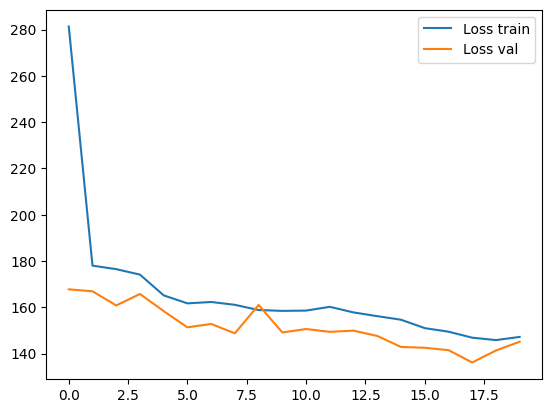

In [90]:
plt.plot(history.history['loss'], label='Loss train')
plt.plot(history.history['val_loss'], label='Loss val')
plt.legend()
plt.show()

La courbe d'apprentissage du MLP montre une convergence progressive. La `Loss train` part d'une valeur élevée (~280) et descend rapidement pour rejoindre la `Loss val` (~150 après 20 epochs). Après 2 epochs, les deux courbes évoluent de façon parallèle et proche, ce qui indique une **absence de surapprentissage** notable : le modèle généralise correctement. La convergence n'est cependant pas encore atteinte à 20 epochs, ce qui suggère qu'un entraînement plus long pourrait améliorer les performances.

In [91]:
from sklearn.metrics import r2_score

results_mean = []
results_std = []
hidden_list = range(1, 10)

for n_hidden in hidden_list:
    r2_scores = []
    
    for i in range(10):
        keras_model = Sequential()
        keras_model.add(Dense(n_hidden, input_dim=n_features, activation='sigmoid'))
        keras_model.add(Dense(1, activation='linear'))  # sortie régression

        keras_model.compile(optimizer=SGD(learning_rate=0.3),
                            loss='mse')  # la loss reste MSE, mais la métrique sera R²

        keras_model.fit(Xr_train_r, y_train_r,
                        epochs=20, batch_size=32, verbose=0,
                        validation_data=(Xr_test_r, y_test_r))

        # prédictions sur le test
        y_pred = keras_model.predict(Xr_test_r, verbose=0)

        # calcul du R²
        r2 = r2_score(y_test_r, y_pred)
        r2_scores.append(r2)

    results_mean.append(np.mean(r2_scores))
    results_std.append(np.std(r2_scores))

    print(f"{n_hidden} neurones : R² moyen = {np.mean(r2_scores):.4f}, écart-type = {np.std(r2_scores):.4f}")


#Sélectionner le meilleur n_hidden et faire le fit dessus pour apres pouvoir le comparer (cf cellule comparaison)
# keras_modelOpt_r = ...
best_n = list(hidden_list)[np.argmax(results_mean)]
print(f"Meilleur nombre de neurones : {best_n} (R² moyen = {max(results_mean):.4f})")

keras_modelOpt_r = Sequential()
keras_modelOpt_r.add(Dense(best_n, input_dim=n_features, activation='sigmoid'))
keras_modelOpt_r.add(Dense(1, activation='linear'))
keras_modelOpt_r.compile(optimizer=SGD(learning_rate=0.3), loss='mse')
keras_modelOpt_r.fit(Xr_train_r, y_train_r, epochs=20, batch_size=32, verbose=0)


c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

1 neurones : R² moyen = 0.4080, écart-type = 0.0083


c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

2 neurones : R² moyen = 0.5273, écart-type = 0.0178


c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

...

c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

8 neurones : R² moyen = 0.5453, écart-type = 0.0199


c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in th

9 neurones : R² moyen = 0.5192, écart-type = 0.0438
Meilleur nombre de neurones : 4 (R² moyen = 0.5756)


c:\Users\Moi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Le R² moyen croît rapidement de 1 à 4 neurones (de 0.408 à **0.576**), puis diminue progressivement au-delà. Le nombre optimal de neurones dans la couche cachée est donc **4**, avec un R² moyen de 0.576 et un écart-type de 0.022.

L'écart-type croissant avec le nombre de neurones (de 0.008 à 0.044) révèle une instabilité croissante : les architectures plus larges sont plus sensibles à l'initialisation aléatoire des poids. Le modèle optimal avec 4 neurones offre le meilleur compromis entre performance et stabilité.

### V. Comparaison des modeles

In [92]:
# Évaluation finale sur le test set
from sklearn.metrics import mean_absolute_error


models_reg = {
    'Ridge':            (ridge_r.best_estimator_,    Xr_test_r),
    'Lasso':            (lasso_r.best_estimator_,    Xr_test_r),
    'ElasticNet':       (ela_r.best_estimator_,      Xr_test_r),
    'SVR (RBF)':        (svrOpt_rbf.best_estimator_, Xr_test_r),
    'SVR (Linéaire)':   (svrOpt_lin.best_estimator_, Xr_test_r),
    'SVR (Polynomial)': (svrOpt_p.best_estimator_,   Xr_test_r),
    'SVR (Sigmoid)':    (svrOpt_s.best_estimator_,   Xr_test_r),
    'Decision Tree':    (treeG_r,                    Xr_test_r),
    'Random Forest':    (rfOpt_r.best_estimator_,    Xr_test_r),
    'Gradient Boosting':(gbOpt_r.best_estimator_,    Xr_test_r),
    'MLP':              (keras_modelOpt_r,            Xr_test_r),
}

results_reg = {}
for name, (model, X_t) in models_reg.items():
    y_pred = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae  = mean_absolute_error(y_test_r, y_pred)
    r2   = r2_score(y_test_r, y_pred)
    results_reg[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}

results_df_reg = pd.DataFrame(results_reg).T.round(4)
results_df_reg = results_df_reg.sort_values('R²', ascending=False)
print(results_df_reg.to_string())

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
                      RMSE     MAE      R²
Lasso               9.7834  7.7193  0.6945
Ridge               9.7846  7.7257  0.6944
ElasticNet          9.7848  7.7250  0.6944
SVR (Linéaire)      9.7903  7.7336  0.6941
Gradient Boosting   9.8365  7.7692  0.6912
Decision Tree       9.8875  7.8002  0.6880
Random Forest      10.0471  7.9700  0.6778
SVR (Sigmoid)      10.1211  8.0161  0.6731
SVR (RBF)          10.2554  8.1050  0.6643
SVR (Polynomial)   10.3626  8.2375  0.6573
MLP                11.3399  8.9558  0.5896


La comparaison sur le jeu de test révèle un résultat frappant : **les modèles linéaires sont les plus performants**, et l'ensemble des modèles non-linéaires ne parvient pas à les surpasser.

Le **LASSO** est le meilleur modèle avec un R² de **0.6945** et un RMSE de **9.78 mg/dL**, suivi de très près par Ridge et Elastic Net. Le SVR linéaire (R² = 0.6941) confirme lui aussi la prédominance de la composante linéaire. Le Gradient Boosting (R² = 0.6912) et l'arbre de décision (R² = 0.6880) sont proches mais légèrement inférieurs. La Forêt Aléatoire (R² = 0.6778) et les SVR à noyaux complexes peinent davantage. Le **MLP** est nettement en retrait avec un R² de **0.5896** et un RMSE de **11.34 mg/dL**, soit environ 16% d'erreur supplémentaire par rapport au LASSO.

L'absence de gain des modèles non-linéaires confirme que la relation entre les variables explicatives et `Cholesterol_LDL` est **essentiellement linéaire**, dominée par `Cholesterol_Total`.

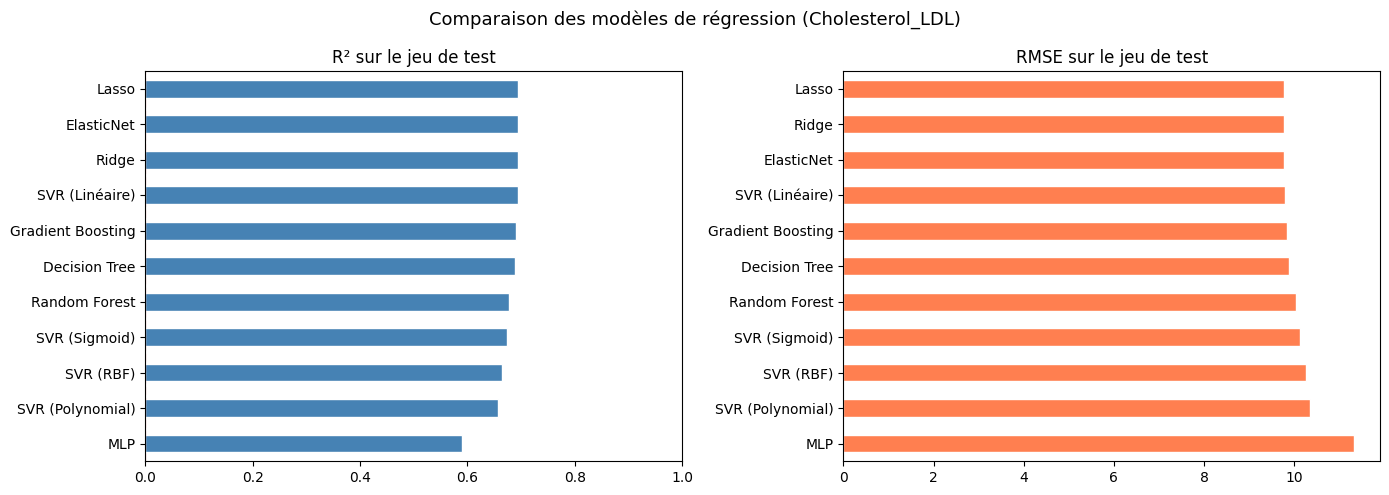

In [93]:
# Graphique comparatif (régression)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df_reg['R²'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('R² sur le jeu de test'); axes[0].set_xlim(0, 1.0)
axes[0].axvline(0, color='red', linestyle='--')

results_df_reg['RMSE'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('RMSE sur le jeu de test')

plt.suptitle('Comparaison des modèles de régression (Cholesterol_LDL)', fontsize=13)
plt.tight_layout()
plt.savefig('reg_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Le graphique en barres illustre visuellement la hiérarchie des modèles. Les **modèles linéaires et le SVR linéaire forment un groupe homogène en tête** (~R² 0.694). Le Gradient Boosting et l'arbre de décision constituent un deuxième groupe (~0.688–0.691). La Forêt Aléatoire et les SVR à noyaux complexes forment un troisième groupe (~0.657–0.678). Le MLP se démarque nettement en bas du classement avec un RMSE significativement plus élevé.

Cette structure en groupes confirme que **la complexité du modèle ne se traduit pas ici en gain de performance** : le problème est fondamentalement linéaire.

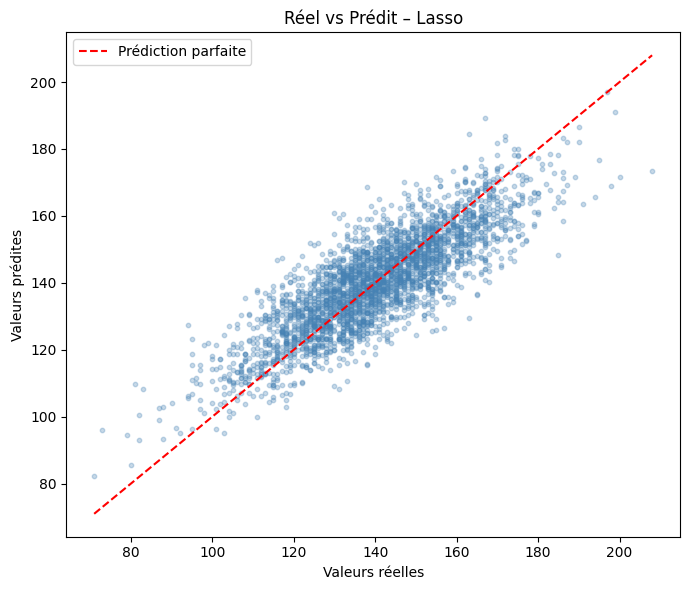

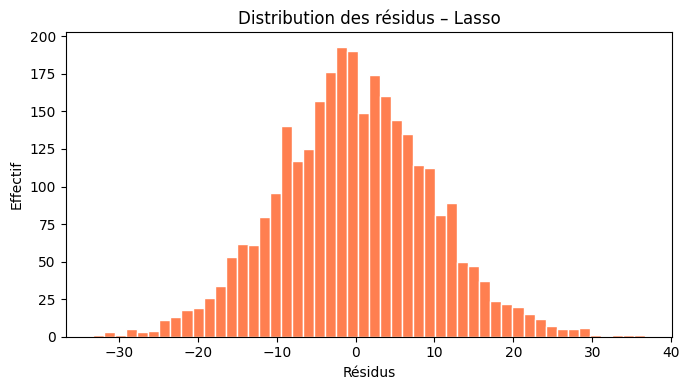

In [94]:
# Graphe valeurs prédites vs réelles du meilleur modèle
best_reg_name = results_df_reg.index[0]
best_reg_model, best_reg_Xt = models_reg[best_reg_name]
y_pred_best_r = best_reg_model.predict(best_reg_Xt)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_best_r, alpha=0.3, s=10, color='steelblue')
mn, mx = y_test_r.min(), y_test_r.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Prédiction parfaite')
plt.xlabel('Valeurs réelles'); plt.ylabel('Valeurs prédites')
plt.title(f'Réel vs Prédit – {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.savefig('reg_pred_vs_real.png', dpi=100, bbox_inches='tight')
plt.show()

# Résidus
residuals = y_test_r - y_pred_best_r
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50, color='coral', edgecolor='white')
plt.xlabel('Résidus'); plt.ylabel('Effectif')
plt.title(f'Distribution des résidus – {best_reg_name}')
plt.tight_layout()
plt.savefig('reg_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

Le nuage de points prédit vs réel pour le meilleur modèle (LASSO) montre que les prédictions suivent bien la tendance globale : les points s'alignent autour de la diagonale de prédiction parfaite. La dispersion reste néanmoins importante (nuage en ellipse allongée), ce qui traduit une **erreur résiduelle non négligeable** (RMSE ≈ 9.78 mg/dL). Le léger décalage angulaire observé est minimal et non significatif.

La distribution des résidus suit visuellement une **loi normale centrée en zéro**, ce qui valide les hypothèses du modèle linéaire et confirme l'absence de biais systématique dans les prédictions du LASSO.

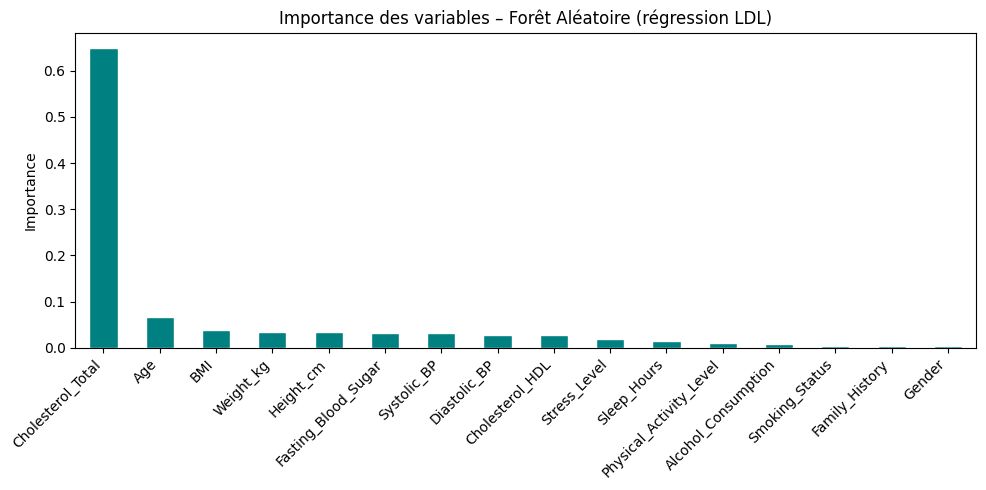

Top 5 : {'Cholesterol_Total': 0.6497919113696824, 'Age': 0.06595923640022376, 'BMI': 0.038281541479624155, 'Weight_kg': 0.034170299757748344, 'Height_cm': 0.032958486353375595}


In [95]:
# Importance des variables pour la régression (RF)
rf_r_best = rf_r.best_estimator_
feat_imp_r = pd.Series(rf_r_best.feature_importances_, index=X_train_r.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp_r.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Importance des variables – Forêt Aléatoire (régression LDL)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feat_imp_reg.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 5 :", feat_imp_r.head(5).to_dict())

`Cholesterol_Total` domine très largement l'importance des variables avec un score de **0.650**, représentant plus de dix fois l'importance de la deuxième variable (`Age` : 0.066). Ce résultat est pleinement cohérent avec la forte colinéarité observée lors de l'analyse exploratoire.

Les variables de corpulence (`BMI`, `Weight_kg`, `Height_cm`) et de pression artérielle (`Systolic_BP`, `Diastolic_BP`) occupent des rangs intermédiaires avec des importances similaires (~0.03). À l'inverse, les variables qualitatives (`Smoking_Status`, `Family_History`, `Gender`) sont en bas du classement avec des importances négligeables, ce qui contraste fortement avec leur rôle prépondérant en classification.

**Retour sur l'analyse exploratoire :** ces résultats sont pleinement cohérents avec nos observations antérieures. La matrice de corrélations montrait déjà que `Cholesterol_Total` était de loin la variable la plus corrélée avec `Cholesterol_LDL`. De même, l'ACP avait mis en évidence que ces deux variables se projetaient dans la même direction sur la Dim 1. Enfin, le fait que les variables qualitatives soient peu importantes confirme notre conclusion exploratoire : ces variables portent un signal prédictif pour le risque cardiaque, mais pas pour le taux de LDL.